In [1]:
import torch 
import torch.nn as nn 
from PIL import Image
import os 
import shutil
import glob
import torch.optim as optim 
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.datasets import ImageFolder
from torchvision import transforms, models
from data_transform import offset_crop, conditional_resize_pad, PercentileNormalize, RayleighMatchTensor , LoadUint16TIff, gamma
import matplotlib.pyplot as plt 
from skimage.filters import median

#### Create Dataset 

In [147]:
# name images indside the data folder 

import glob 
image_dir  = "/home/sphere/Morpheus/new_train_DATA/Fighter/mig31_0refl_subpart2_0.8pix_0.7ham_low_noise"
image_paths = glob.glob(image_dir+'/*')

In [148]:
def rename_images(image_dir):
    image_paths = glob.glob(image_dir+'/*')
    for image in image_paths:
        basename = os.path.basename(image)
        angle = basename.split('_')[-3][2:]
        dirname = os.path.basename(image_dir)
        new_name = os.path.join(dirname+"_"+angle+".png")
        os.rename(image, os.path.join(image_dir, new_name))
    print('done')

In [149]:
rename_images(image_dir)

done


### Hyperparameters and Directory

In [2]:
train_dir = "TU95Classification/train" 
val_dir = "TU95Classification/val"
checkpoint_dir = "/media/sphere/744c0eb8-a6d5-469f-9d27-449a9eef9aa1/home/admin123/Kanishk/classification/checkpoint"
checkpoint_name = "Bomber_vs_fighter_subparts_mblv3_freeze_bbone_resize_100ep"
batch_size = 8
num_classes =2
num_epochs = 100
learning_rate = 5e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# writer = SummaryWriter("runs/experiment_FB_subparts_lr_5e4_16batch_mobilenet_v3_feeze_bbone_resize_100ep")


### Data Transformation

In [3]:
import numpy as np
from scipy.stats import truncnorm
def clip(image1, min=0.25, max=99.5):
    min = np.percentile(image1, min)
    max = np.percentile(image1, max)
    image = np.clip(image1, min, max)
    image = (image - image.min())/(image.max() - image.min())
    return image 
def gamma_enh(image, param, clipin = True, min = 0.25, max = 99.5):
    image = image**(1/param)
    
    if clipin:
        image = clip(image, min, max)
    else:
        image = (image - image.min())/(image.max() - image.min())
    return image 
def sample_gaussian_in_range(mu, sigma, low, high, n=1):
    # Convert boundaries to standard normal units
    a = (low - mu) / sigma
    b = (high - mu) / sigma

    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=n)

# Example
vals = sample_gaussian_in_range(mu=13, sigma=1, low=10, high=15, n=1)
vals

array([13.68335191])

In [4]:
np.array([1,2]).mean()

np.float64(1.5)

In [5]:
# capella augmentation

def capella_augmentation(image,  gamma_stretch = [0.5, 1.2], additive = [0.7, 2.2]):

    gst = sample_gaussian_in_range(np.array(gamma_stretch).mean(), 1.5, gamma_stretch[0], gamma_stretch[1])
    add = sample_gaussian_in_range(np.array(additive).mean(), 1.5, additive[0], additive[-1])
    return clip(gamma_enh(image, gst)+ np.random.gamma(add, 1/20, image.shape), min =1 ,max = 99.25)

In [6]:
# gamma_filter - np.random.normal()
# gamma_enhance - 
# gamma_clutter - 

def mig_aug_train(gamma_stretch = [0.5, 1.2], additive = [0.7, 2]):
    def augmentation(img):
        arr = img.numpy()
        arr =(arr - arr.min())/(arr.max() - arr.min())
        gst = sample_gaussian_in_range(np.array(gamma_stretch).mean(), 1.5, gamma_stretch[0], gamma_stretch[1])
        add = sample_gaussian_in_range(np.array(additive).mean(), 1.5, additive[0], additive[-1])
        arr = clip(gamma_enh(arr, gst)+ np.random.gamma(add, 1/20, arr.shape), min =1 ,max = 99.25)
        if arr.ndim ==2:
            arr = np.stack([arr,arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return augmentation

def tu_aug_train( paraml = [0.7, 1.1] ,g_enh = [0.35, 1], clutter = [0.7, 1.8], percentiles = [0.25, 99.5]):
    # Convert tensor image to numpy array
    def apply_gamma(img):
        arr = img.numpy()

        # normalize to 0..1 if needed
        arr /= arr.max() + 1e-8

        # gamma correction
        param = sample_gaussian_in_range((paraml[0]+paraml[1])/2, 1.5,low = paraml[0], high =paraml[-1])
        enh = sample_gaussian_in_range((g_enh[0]+g_enh[1])/2, 1.5,low= g_enh[0], high=g_enh[-1])
        cl = sample_gaussian_in_range((clutter[0]+clutter[1])/2, 1.5, clutter[0], clutter[-1])
        
        cl_denom = sample_gaussian_in_range(15,sigma=1.5,low = 10, high=20)
        
        # percentile clipping
        # lo = np.percentile(arr, minp)
        # hi = np.percentile(arr, maxp)
        # arr = np.clip(arr, lo, hi)

        # # scale 0..1
        # arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        arr = clip(gamma_enh(arr*np.random.gamma(param, 1/20),enh, arr.shape) + np.random.gamma(cl, 1/cl_denom, arr.shape))
        if arr.ndim == 2:
            arr = np.stack([arr,arr, arr], axis = 0)

        # convert back to PIL image if needed
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return apply_gamma

train_class_tranform = {"fighter": transforms.Compose([transforms.Lambda(offset_crop), 
                                    transforms.ToTensor(), 
                                    transforms.Lambda(mig_aug_train()),
                                    transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224,0.225])]),
                        "Tu_95": transforms.Compose([transforms.Lambda(offset_crop),
                                    transforms.ToTensor(), 
                                    transforms.Lambda(tu_aug_train()),
                                    transforms.Normalize(mean= [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])}
val_class_transform = {"fighter": transforms.Compose([LoadUint16TIff(gamma=1, minp=0, maxp=95, img_size=128)]),
                        "Tu_95": transforms.Compose([LoadUint16TIff(gamma =1, minp =10, maxp = 99, img_size =128),
                                transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])])}

In [7]:
def path_loader(path):
    return path   # Important
train_transform = transforms.Compose([transforms.Lambda(offset_crop), 
                                      transforms.ToTensor(),
                                      transforms.Lambda(tu_aug_train()),
                                      transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])
                                      ])
val_transform = transforms.Compose([LoadUint16TIff(gamma= 1, minp = 10,maxp  = 99, img_size=128 ),
                                    transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])])

train_dataset = ImageFolder(root = train_dir, transform = train_transform)
val_dataset = ImageFolder(root=val_dir,loader= path_loader ,transform= val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = True)
train_loader  = DataLoader(train_dataset, batch_size= batch_size, shuffle = True)

In [8]:
list(train_dataset.class_to_idx.keys())

['Chinook', 'TU_95']

In [9]:
import numpy as np 
train_im , train_labels = next(iter(train_loader))
val_im, val_labels = next(iter(val_loader))





TypeError: pic should be PIL Image or ndarray. Got <class 'function'>

NameError: name 'train_im' is not defined

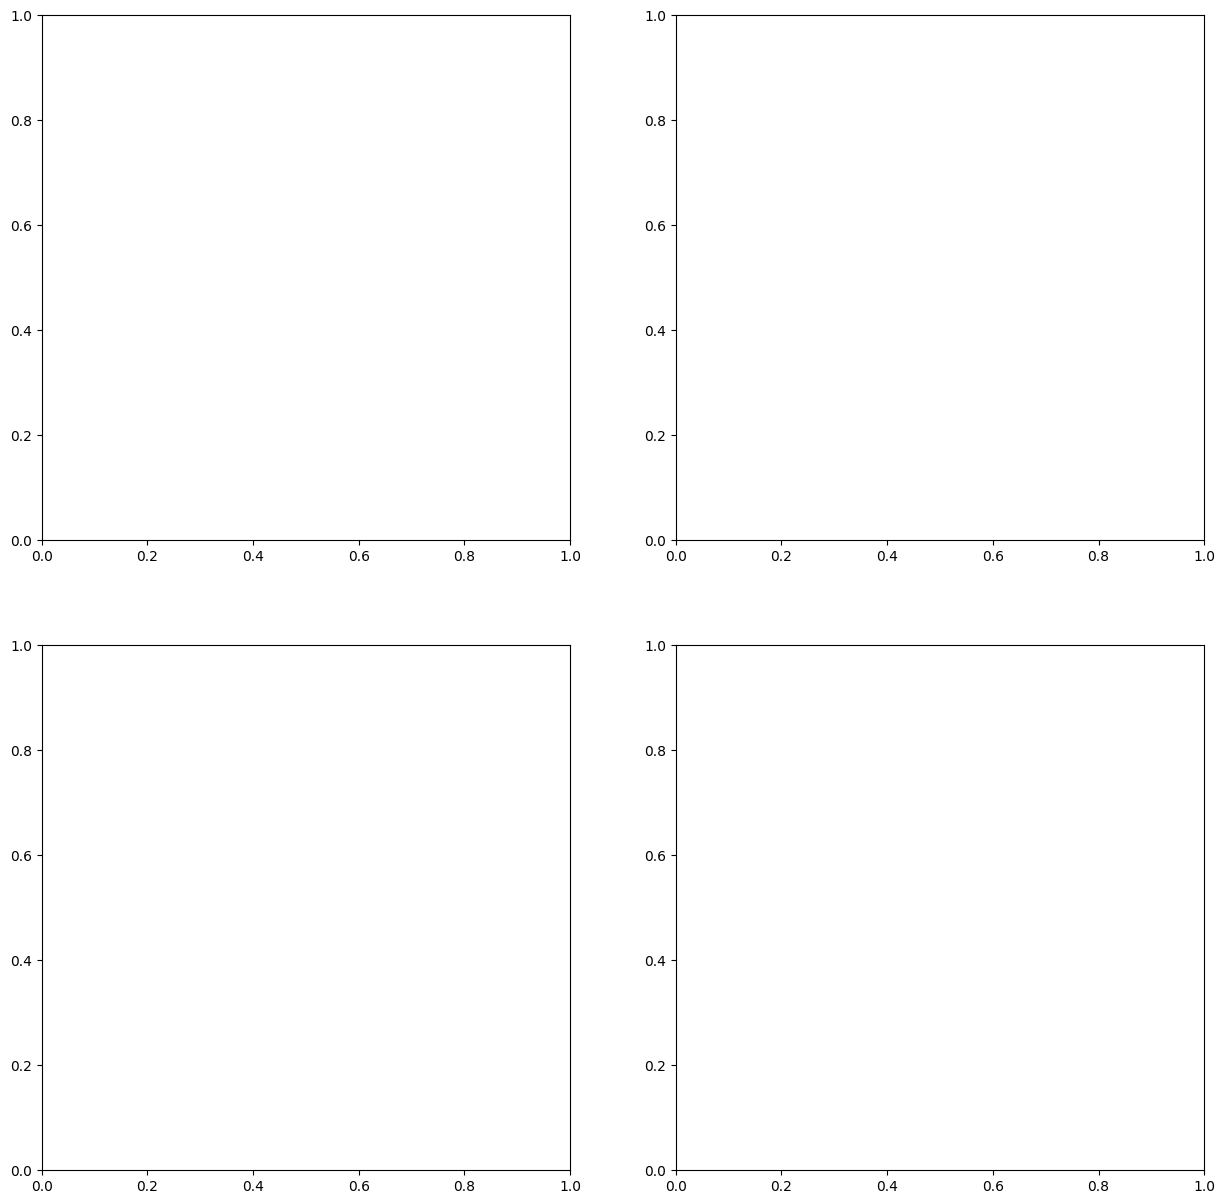

In [10]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[-1,0], 'gray')
ax[0,1].imshow(val_im[2,0], 'gray')
ax[1,0].hist(train_im[5,0].ravel(), bins = 200)
ax[1,1].hist(val_im[1,0].ravel(), bins = 200)
plt.show()

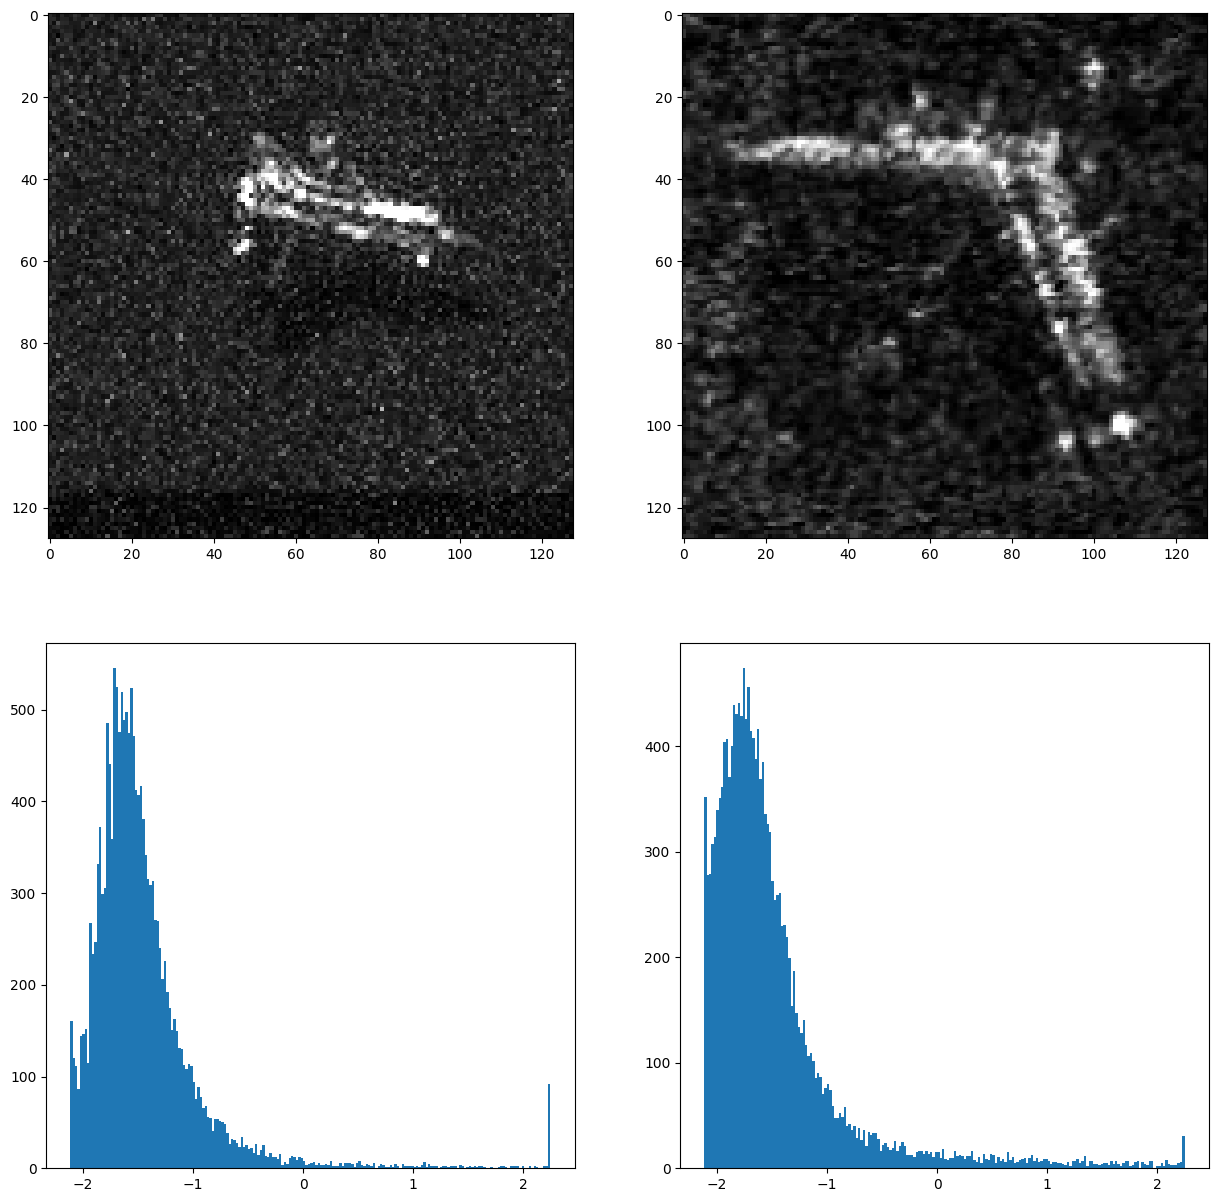

In [98]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[6, 0], 'gray')
ax[0,1].imshow(val_im[2,0], 'gray')
ax[1,0].hist(train_im[6,0].ravel(), bins = 200)
ax[1,1].hist(val_im[2,0].ravel(), bins = 200)
plt.show()

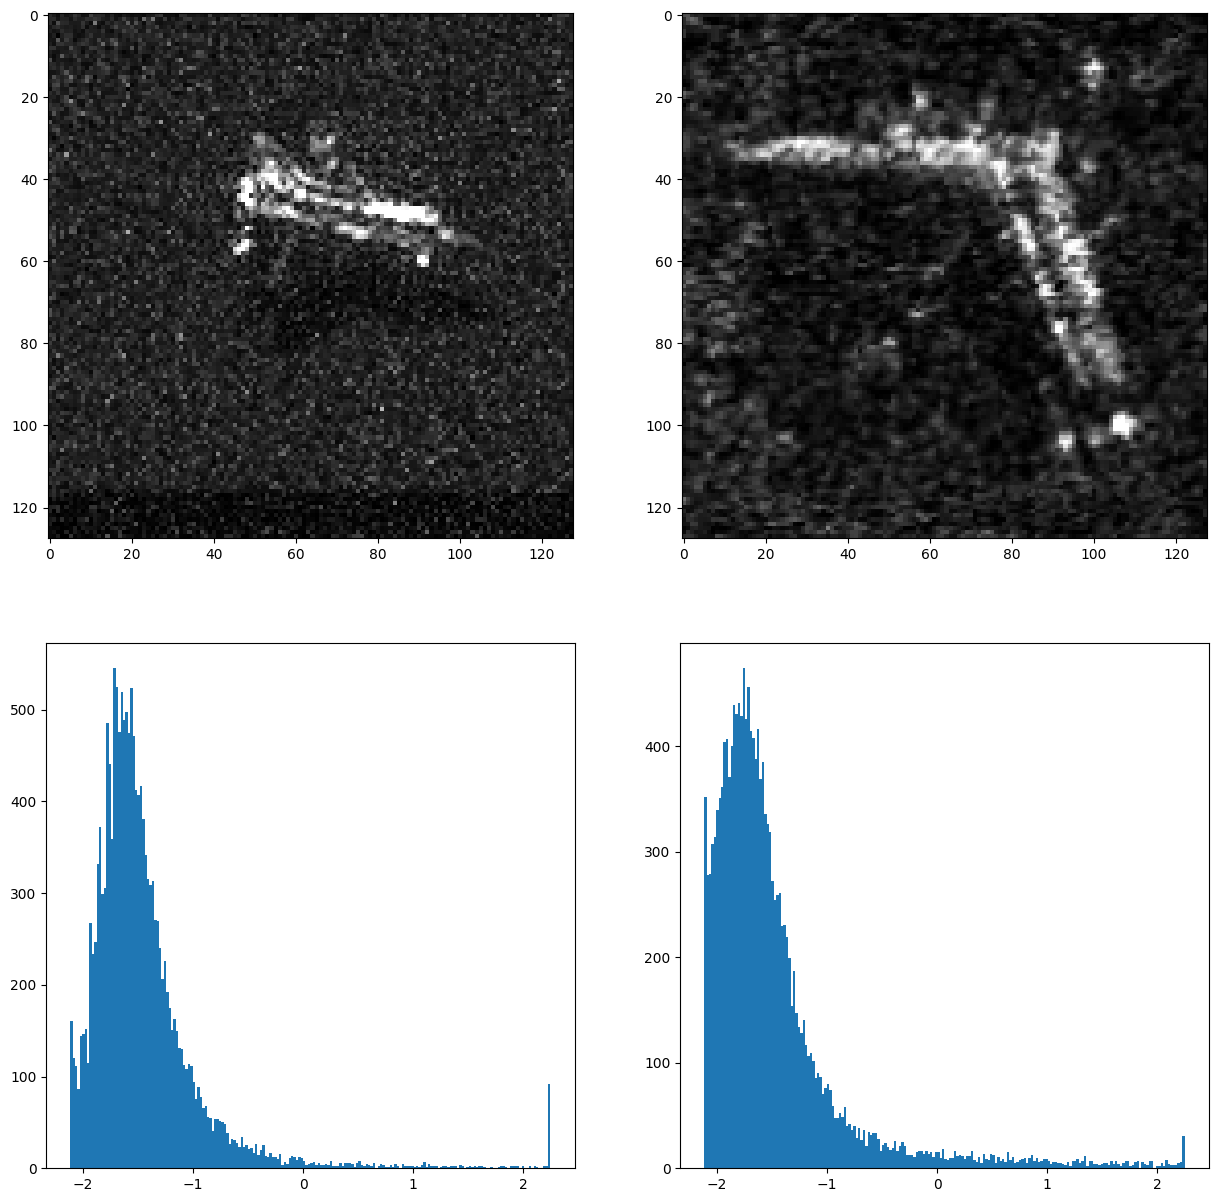

In [99]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[6, 0], 'gray')
ax[0,1].imshow(val_im[2,0], 'gray')
ax[1,0].hist(train_im[6,0].ravel(), bins = 200)
ax[1,1].hist(val_im[2,0].ravel(), bins = 200)
plt.show()

### Defining Model

In [100]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
# adjusting the model for custom classes
for param in model.parameters():
    param.requires_grad = False
num_features = model.classifier[-1].in_features
for param in model.classifier.parameters():
    param.requires_grad = True
model.classifier[-1] = nn.Linear(num_features, num_classes)

model.to(device)
# num_features = model.fc.in_features
# model.fc = nn.Linear(num_features, num_classes)
# model.to(device=device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

### Loss And Optimizer

In [101]:
criterion = nn.CrossEntropyLoss()
param_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(param_to_update, lr = learning_rate)

### Training Loop 

In [102]:
best_val_acc = 0.0
checkpoint = os.path.join(checkpoint_dir, checkpoint_name)

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    val_run_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*images.size(0)
        _ , predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    train_acc = 100*correct/total
    train_loss = running_loss/len(train_loader.dataset)
    writer.add_scalar("Train/Loss", train_loss, epoch)
    writer.add_scalar("Train/Accuracy", train_acc ,epoch)


    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            val_run_loss += v_loss.item()*images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total+=labels.size(0)
            val_correct  += (predicted==labels).sum().item()
    val_loss = val_run_loss/len(val_loader.dataset)
    val_acc = 100*val_correct/val_total
    writer.add_scalar("Val/Loss", val_loss, epoch)
    writer.add_scalar("Val/Accuracy", val_acc, epoch)

    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train acc: {train_acc: .2f}%")
    print(f"Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc=val_acc
        torch.save(model.state_dict(), checkpoint)

print("training Complete. Best accuracy:", best_val_acc)





Epoch 0/100
Train Loss: 0.4651, Train acc:  77.55%
Val Acc: 73.81%
Epoch 1/100
Train Loss: 0.4487, Train acc:  80.32%
Val Acc: 42.86%
Epoch 2/100
Train Loss: 0.3784, Train acc:  83.80%
Val Acc: 35.71%
Epoch 3/100
Train Loss: 0.3351, Train acc:  86.81%
Val Acc: 52.38%
Epoch 4/100
Train Loss: 0.3695, Train acc:  85.19%
Val Acc: 45.24%
Epoch 5/100
Train Loss: 0.3831, Train acc:  85.19%
Val Acc: 23.81%
Epoch 6/100
Train Loss: 0.3260, Train acc:  86.81%
Val Acc: 14.29%
Epoch 7/100
Train Loss: 0.3434, Train acc:  85.65%
Val Acc: 45.24%
Epoch 8/100
Train Loss: 0.3369, Train acc:  86.81%
Val Acc: 54.76%
Epoch 9/100
Train Loss: 0.3471, Train acc:  84.72%
Val Acc: 42.86%
Epoch 10/100
Train Loss: 0.2932, Train acc:  87.73%
Val Acc: 38.10%
Epoch 11/100
Train Loss: 0.3170, Train acc:  86.57%
Val Acc: 50.00%
Epoch 12/100
Train Loss: 0.2926, Train acc:  88.19%
Val Acc: 52.38%
Epoch 13/100
Train Loss: 0.3584, Train acc:  85.42%
Val Acc: 64.29%
Epoch 14/100
Train Loss: 0.3488, Train acc:  85.42%
Val Ac

KeyboardInterrupt: 

#### For mobilenetv3 60% acc full model paths 

In [ ]:
def path_loader(path):
    return path   # Important
train_transform = transforms.Compose([transforms.Lambda(offset_crop), 
                                      transforms.ToTensor(),
                                      transforms.Lambda(gamma(param=.47, minp =1 , maxp = 99.5)),
                                      transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])
                                      ])
val_transform = transforms.Compose([LoadUint16TIff(gamma= 0.35, minp = 10,maxp  = 99, img_size=128 ),
                                    transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])])

train_dataset = ImageFolder(root = train_dir, transform=train_transform)
val_dataset = ImageFolder(root=val_dir,loader= path_loader ,transform= val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = True)
train_loader  = DataLoader(train_dataset, batch_size= batch_size, shuffle = True)

### For Mobilenetv3 75% acc freeze backbone 
- checkpoint_name: "Bomber_vs_helicopter_subparts_mblv3_val_g0.4_freeze_bbone"
- checkpoint/75_Bomber_vs_helicopter_subparts_mblv3_val_g0.4_freeze_bbone_75acc


In [ ]:
def path_loader(path):
    return path   # Important
train_transform = transforms.Compose([transforms.Lambda(offset_crop), 
                                      transforms.ToTensor(),
                                      transforms.Lambda(gamma(param=.47, minp =1 , maxp = 99.5)),
                                      transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])
                                      ])
val_transform = transforms.Compose([LoadUint16TIff(gamma= 0.4, minp = 10,maxp  = 99, img_size=128 ),
                                    transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])])

train_dataset = ImageFolder(root = train_dir, transform=train_transform)
val_dataset = ImageFolder(root=val_dir,loader= path_loader ,transform= val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = True)
train_loader  = DataLoader(train_dataset, batch_size= batch_size, shuffle = True)